# Толстые и тонкие линии морфологией

Без скелета: ширина штриха — диаметр вписанного круга (2·dist) в точках середины штриха.
Порядок: лист → без текста → без таблиц → классы ширины (при необходимости ×2) → два класса → толстая маска.

In [1]:
from pathlib import Path

import cv2
import ipywidgets as widgets
import numpy as np
from IPython.display import display
from matplotlib import pyplot as plt
from scipy import ndimage

from draftslice.core.io import load_image
from draftslice.core.utils.image_utils import binarize_image, rgb_to_grayscale

files = sorted(Path("../data/images").glob("*.jpg")) + sorted(Path("../data/drawing").glob("*.png"))
print(f"Чертежей: {len(files)}")


def load_sheet(file: Path):
    """Изображение листа (RGB) и полигоны OCR из кэша, (N, 4, 2) в px листа.

    Кэш пишет thick_lines.py, пробелы в имени файла там заменены на '_'. Нет кэша - FileNotFoundError.
    """
    img = load_image(str(file))
    polys = np.load(f".cache/ocr_cache/{file.stem.replace(' ', '_')}.npy")
    return img, polys


def _view_img(filename: str):
    path = next(f for f in files if f.name == filename)
    img, polys = load_sheet(path)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.title(img.shape)
    plt.axis("off")
    plt.show()
    return img, polys


ui = widgets.interactive(_view_img, filename=[f.name for f in files])
display(ui)

Чертежей: 30


interactive(children=(Dropdown(description='filename', options=('1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg…

## Текст

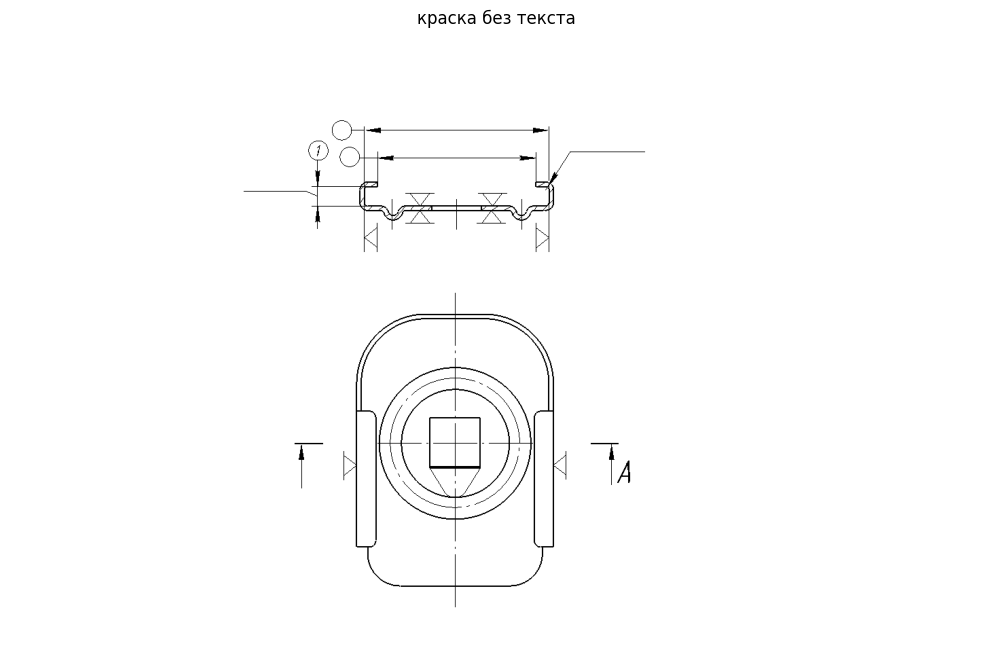

In [93]:
def get_half_wide_box(poly):
    """Возвращает bounding box полигона, расширенный на полвысоты строки."""
    (cx, cy), (w, h), a = cv2.minAreaRect(poly)
    m = min(w, h) / 2
    return np.round(cv2.boxPoints(((cx, cy), (w + 2 * m, h + 2 * m), a))).astype(np.int32)


def draw_tight_mask_and_get_boxes(shape, polys):
    """Создает точную маску полигонов и список расширенных боксов."""
    tight = np.zeros(shape, np.uint8)
    wide_boxes = []

    for poly in polys:
        # cv2.fillConvexPoly работает in-place, заливаем точную маску
        cv2.fillConvexPoly(tight, np.round(poly).astype(np.int32), 1)
        wide_boxes.append(get_half_wide_box(poly))

    return tight, wide_boxes


def check_components_in_wide_boxes(labels, binary, wide_boxes, comp_area, n_cc):
    """Проверяет, лежит ли каждая компонента ЦЕЛИКОМ внутри хотя бы одного wide_box."""
    img_h, img_w = binary.shape
    in_one_wide = np.zeros(n_cc, bool)

    for box in wide_boxes:
        # Ограничиваем координаты рамки размерами изображения
        x0, y0 = np.maximum(box.min(0), 0)
        x1, y1 = np.minimum(box.max(0) + 1, (img_w, img_h))

        # Создаем локальную маску (ROI) для текущего бокса
        roi = np.zeros((y1 - y0, x1 - x0), np.uint8)
        cv2.fillConvexPoly(roi, box - (x0, y0), 1)

        # Пиксели, принадлежащие и расширенному боксу, и исходным линиям
        sel = (roi > 0) & binary[y0:y1, x0:x1]

        local_labels = labels[y0:y1, x0:x1][sel]
        if local_labels.size > 0:
            # Считаем только те метки, которые есть в рамке (без minlength)
            local_counts = np.bincount(local_labels)

            # Получаем индексы только присутствующих компонент (исключая фон 0)
            present_labels = np.nonzero(local_counts)[0]
            if present_labels[0] == 0:
                present_labels = present_labels[1:]

            # Проверяем площадь только для них и точечно обновляем in_one_wide
            is_full_inside = local_counts[present_labels] == comp_area[present_labels]
            in_one_wide[present_labels[is_full_inside]] = True

    return in_one_wide


def clear_text(binary, polys):
    # Каждую полигонную область уменьшаем и закрашиваем
    tight_mask, wide_boxes = draw_tight_mask_and_get_boxes(binary.shape, polys)

    # Ищем связные компоненты
    n_cc, labels, stats, _ = cv2.connectedComponentsWithStats(binary.astype(np.uint8), connectivity=8)
    comp_area = stats[:, cv2.CC_STAT_AREA]

    # Компонента более чем на 50% площади лежит в точных полигонах
    valid_tight_pixels = (binary > 0) & (tight_mask == 1)
    in_tight = np.bincount(labels[valid_tight_pixels], minlength=n_cc)
    is_mostly_in_tight = 2 * in_tight > comp_area

    # Компонента целиком лежит внутри одной расширенной рамки
    is_entirely_in_wide = check_components_in_wide_boxes(labels, binary, wide_boxes, comp_area, n_cc)

    # Объединяем условия (0-й индекс — это фон, его исключаем)
    is_text_cc = is_mostly_in_tight | is_entirely_in_wide
    is_text_cc[0] = False

    # Очищаем текст
    ink = binary & ~is_text_cc[labels]

    return ink.astype(np.uint8) * 255


img, polys = ui.result
ink = clear_text(binarize_image(rgb_to_grayscale(img)) > 0, polys)

plt.figure(figsize=(16, 8))
plt.imshow(255 - ink, cmap="gray")
plt.title("краска без текста")
plt.axis("off")
plt.show()

## Ширина штрихов

In [94]:
def otsu(x):
    """Порог Otsu по значениям x; разрез только между разными значениями."""
    x = np.sort(x.astype(np.float64))
    n, c = len(x), np.cumsum(x)
    w0 = np.arange(1, n)
    m0, m1 = c[:-1] / w0, (c[-1] - c[:-1]) / (n - w0)
    between = w0 * (n - w0) * (m0 - m1) ** 2
    between[x[1:] == x[:-1]] = -1
    j = int(np.argmax(between))
    return 0.5 * (x[j] + x[j + 1])


def stroke_ridge(ink):
    """Карта расстояний до фона и середины штрихов (локальный максимум карты расстояний)."""
    dist = cv2.distanceTransform(ink, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
    ridge = (dist >= cv2.dilate(dist, np.ones((3, 3), np.uint8))) & (dist > 0)
    return dist, ridge


def width_classes(dist, ridge):
    """Порог между тонкими и толстыми и медианы классов по ширине штрихов (2·dist в серединах), px."""
    width = 2 * dist[ridge]
    thr = otsu(width)
    return thr, np.median(width[width <= thr]), np.median(width[width > thr])


thr, thin, thick = width_classes(*stroke_ridge(ink))
print(f"лист {ink.shape}: тонкие {thin:.1f} px, толстые {thick:.1f} px, порог {thr:.2f}")

лист (907, 1431): тонкие 2.0 px, толстые 4.0 px, порог 3.41


## Таблицы

краски удалено как таблицы: 0 px


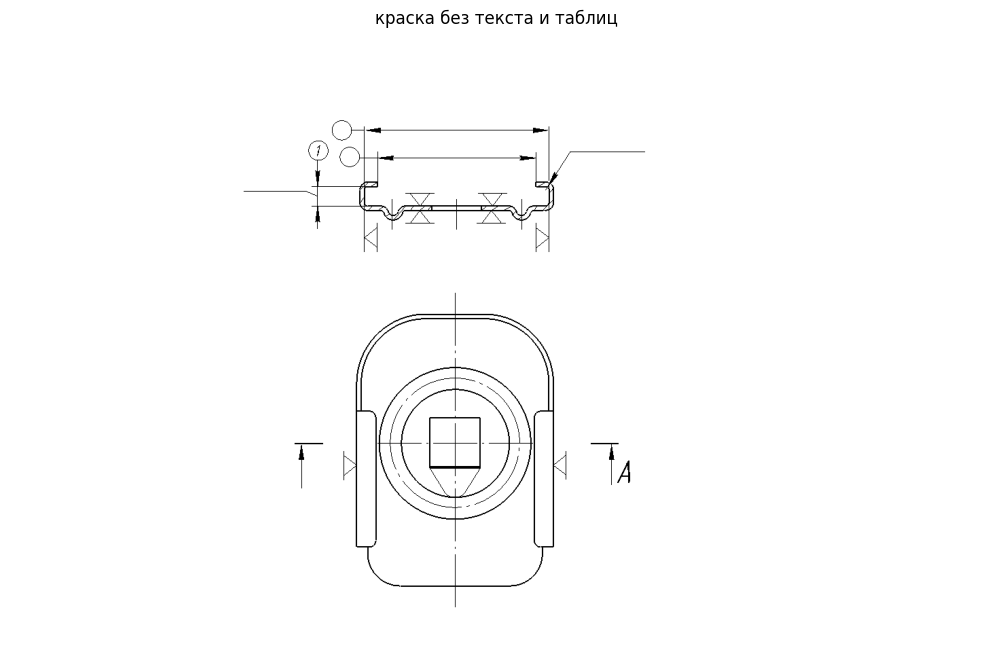

In [95]:
def table_cells(ink, polys, min_rect=0.85):
    """
    Кандидаты в ячейки таблиц: связные области фона не у края листа, почти прямоугольные
    (площадь / площадь рамки ≥ min_rect), с центром хотя бы одной надписи OCR.
    -> метки фона (H, W), номера ячеек, stats фона
    """
    n, lab, st, _ = cv2.connectedComponentsWithStats((ink == 0).astype(np.uint8), connectivity=4)
    x, y, w, h, area = st[:, 0], st[:, 1], st[:, 2], st[:, 3], st[:, 4]
    img_h, img_w = ink.shape
    inner = (x > 0) & (y > 0) & (x + w < img_w) & (y + h < img_h)  # не касается края листа
    rect = area / np.maximum(w * h, 1)
    c = np.rint(polys.mean(axis=1)).astype(int) if len(polys) else np.zeros((0, 2), int)  # центры надписей (x, y)
    c = c[(c[:, 0] >= 0) & (c[:, 0] < img_w) & (c[:, 1] >= 0) & (c[:, 1] < img_h)]
    n_text = np.bincount(lab[c[:, 1], c[:, 0]], minlength=n)
    cell = inner & (rect >= min_rect) & (n_text > 0)
    cell[0] = False
    return lab, np.flatnonzero(cell), st


def table_groups(lab, cells, gap=3):
    """Номер группы каждой ячейки: ячейки, разделённые стенкой не толще gap px, — одна группа."""
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * gap + 1, 2 * gap + 1))
    grown = cv2.dilate(np.isin(lab, cells).astype(np.uint8), kernel)
    _, grp = cv2.connectedComponents(grown, connectivity=8)
    return ndimage.maximum(grp, lab, cells).astype(int) if len(cells) else np.zeros(0, int)


def remove_tables(ink, polys, margin, min_cells=2):
    """
    Краска без таблиц. Таблица — не меньше min_cells соседних ячеек; её сетка — компоненты краски,
    касающиеся ячеек, в рамке таблицы с запасом margin px (на толщину внешней рамки).
    """
    lab, cells, st = table_cells(ink, polys)
    grp = table_groups(lab, cells)
    ids, cnt = np.unique(grp, return_counts=True)
    _, ink_lab = cv2.connectedComponents(ink, connectivity=8)
    remove = np.zeros(ink.shape, bool)
    for g in ids[cnt >= min_cells]:
        cs = cells[grp == g]
        x0, y0 = st[cs, 0].min(), st[cs, 1].min()
        x1, y1 = (st[cs, 0] + st[cs, 2]).max(), (st[cs, 1] + st[cs, 3]).max()
        ys, xs = slice(max(0, y0 - margin), y1 + margin), slice(max(0, x0 - margin), x1 + margin)
        touch = cv2.dilate(np.isin(lab[ys, xs], cs).astype(np.uint8), np.ones((3, 3), np.uint8)) & (ink[ys, xs] > 0)
        grid = np.isin(ink_lab[ys, xs], np.unique(ink_lab[ys, xs][touch > 0]))  # компоненты краски, касающиеся ячеек
        remove[ys, xs] |= grid & (ink[ys, xs] > 0)
    return np.where(remove, 0, ink).astype(np.uint8)


no_tables = remove_tables(ink, polys, margin=int(np.ceil(thick)) + 1)
print(f"краски удалено как таблицы: {(ink > 0).sum() - (no_tables > 0).sum()} px")

plt.figure(figsize=(16, 8))
plt.imshow(255 - no_tables, cmap="gray")
plt.title("краска без текста и таблиц")
plt.axis("off")
plt.show()

## Подготовка листа

In [96]:
def prepare_ink(img, polys):
    """Краска листа без текста и таблиц (0/255), её карта расстояний, середины штрихов и классы ширины."""
    ink = clear_text(binarize_image(rgb_to_grayscale(img)) > 0, polys)
    dist, ridge = stroke_ridge(ink)
    _, _, thick = width_classes(dist, ridge)  # толщина толстых — для запаса вокруг таблиц
    ink = remove_tables(ink, polys, margin=int(np.ceil(thick)) + 1)
    dist = np.where(ink > 0, dist, 0)  # таблица стёрта целыми компонентами: у остальной краски расстояние до фона прежнее
    ridge &= ink > 0
    return ink, dist, ridge, *width_classes(dist, ridge)



img, polys = ui.result  # заново из виджета: повторный запуск не накапливает увеличение
ink, dist, ridge, thr, thin, thick = prepare_ink(img, polys)
if thick - thin <= 2.5:  # 1 и 2 px на сетке дают одинаковые 2·dist — увеличиваем ×2 до бинаризации
    img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    polys = polys * 2
    ink, dist, ridge, thr, thin, thick = prepare_ink(img, polys)

print(f"лист {img.shape[:2]}: тонкие {thin:.1f} px, толстые {thick:.1f} px, порог {thr:.2f}")

лист (1814, 2862): тонкие 2.0 px, толстые 4.0 px, порог 3.41


## Два класса

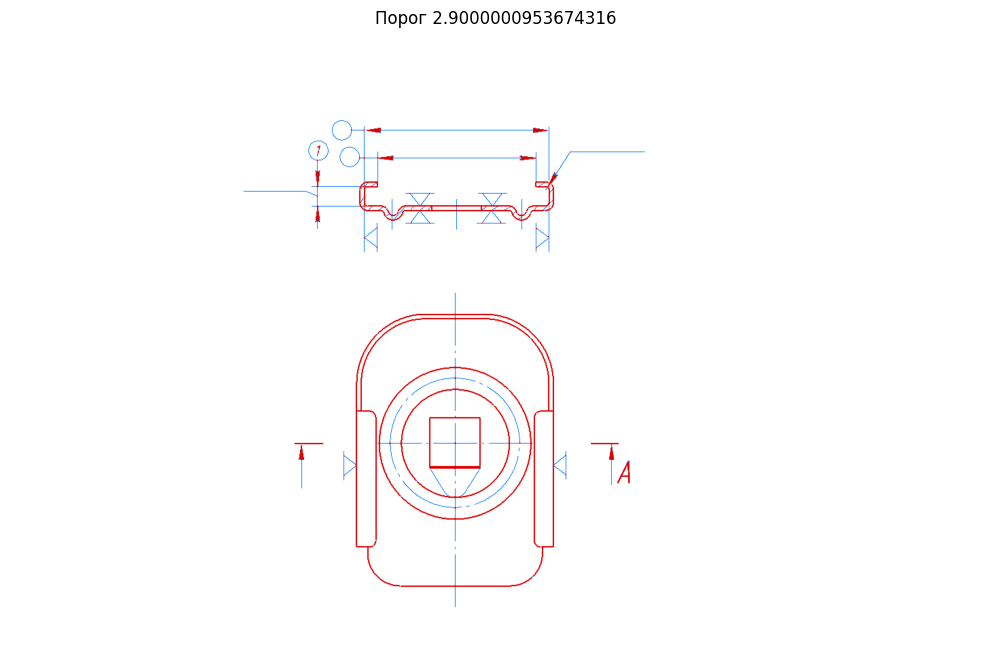

In [97]:
def thick_from(seed, ink, dist):
    """Маска краски в пределах полутолщины от середин толстых штрихов seed (uint8, 0/255)."""
    src = np.where(seed, 0, 255).astype(np.uint8)
    d_seed, near = cv2.distanceTransformWithLabels(src, cv2.DIST_L2, cv2.DIST_MASK_PRECISE, labelType=cv2.DIST_LABEL_PIXEL)
    sy, sx = np.nonzero(seed)
    rad_of = np.zeros(near.max() + 1, np.float32)
    rad_of[near[sy, sx]] = dist[sy, sx]
    return ((ink > 0) & (d_seed <= rad_of[near])).astype(np.uint8) * 255


d_hi = max(thr, np.sqrt(2) * thin)  # уверенно толстое
s = 0.45  # та же доля, что и в пороге по веткам скелета
d_lo = min(thin + s * (thick - thin), d_hi)  # мягкий порог не выше строгого
seed_hi = ridge & (2 * dist >= d_hi)
seed_lo = ridge & (2 * dist >= d_lo)
thick_mask = thick_from(seed_lo, ink, dist)

cls = np.where(ink == 0, 0, np.where(thick_mask > 0, 2, 1))  # 0 фон, 1 тонкая, 2 толстая
colors = np.array([[255, 255, 255], [0, 120, 255], [220, 0, 0]], np.uint8)  # фон, тонкие, толстые

plt.figure(figsize=(16, 8))
plt.imshow(colors[cls])
plt.title(f"Порог {d_lo}")
plt.axis("off")
plt.show()


## Толстая маска

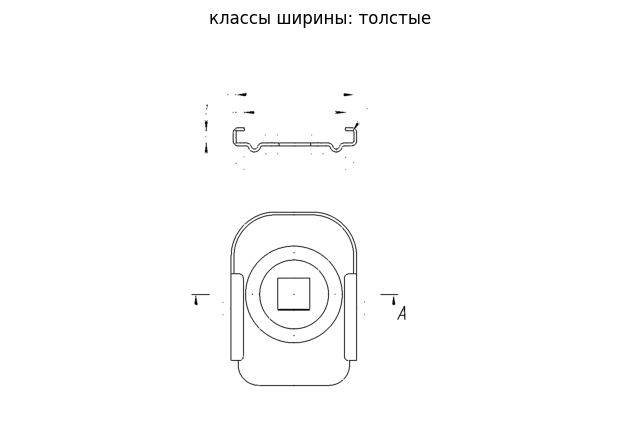

In [98]:
clean = np.where(cls == 2, 255, 0).astype(np.uint8)

plt.figure(figsize=(8, 8))
plt.imshow(255 - clean, cmap="gray")
plt.title("классы ширины: толстые")
plt.axis("off")
plt.show()

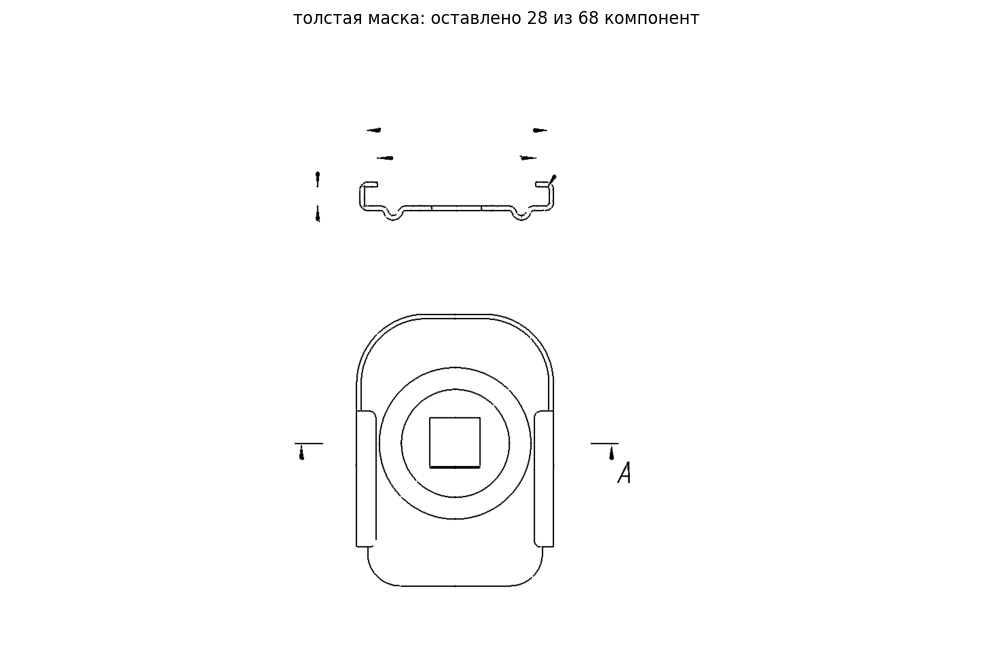

In [99]:
n, lab, _, _ = cv2.connectedComponentsWithStats(thick_mask, connectivity=8)
has_hi = np.bincount(lab[seed_hi], minlength=n) > 0
cnt = np.bincount(lab[seed_lo], minlength=n)
w = np.bincount(lab[seed_lo], weights=2 * dist[seed_lo], minlength=n) / np.maximum(cnt, 1)
keep = has_hi & (cnt >= 2 * w)
keep[0] = False
clean = np.where(keep[lab], 255, 0).astype(np.uint8)

plt.figure(figsize=(16, 8))
plt.imshow(255 - clean, cmap="gray")
plt.title(f"толстая маска: оставлено {keep.sum()} из {n - 1} компонент")
plt.axis("off")
plt.show()
